# Hyperparameter Tuning Visualization: swin_unet
This notebook visualizes the tuning results from `outputs/tuning/swin_unet/summary.json`.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Style configuration
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "figure.titlesize": 16,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

PRIMARY_COLOR = "#1976D2"
SECONDARY_COLOR = "#388E3C"
ACCENT_COLOR = "#D32F2F"
DARK_NEUTRAL = "#37474F"

model_name = "swin_unet"
tuning_dir = Path(f"../outputs/tuning/{model_name}")
summary_path = tuning_dir / "summary.json"

if not summary_path.exists():
    print(f"Error: summary file not found: {summary_path}")
else:
    with summary_path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    trials = data.get("trials", [])
    print(f"Loaded {len(trials)} trials.")


Loaded 10 trials.


In [2]:
# Process trials data
rows = []
for t in trials:
    if t["status"] != "COMPLETE":
        continue
    row = {
        "trial_id": t["trial_id"],
        "duration_sec": t["duration_sec"],
        "status": t["status"],
        "lr": t["params"]["lr"],
        "encoder_lr": t["params"]["encoder_lr"],
        "loss": t["params"]["loss"],
        "dice": t["metrics"].get("dice", 0.0),
        "iou": t["metrics"].get("iou", 0.0),
    }
    rows.append(row)

df = pd.DataFrame(rows)
print(f"Analyzing {len(df)} completed trials...")

best_row = df.loc[df["dice"].idxmax()]
print("\nBest configuration found:")
print(f"  Trial ID     : #{best_row['trial_id']}")
print(f"  Val Dice     : {best_row['dice']:.4f}")
print(f"  Decoder LR   : {best_row['lr']:.2e}")
print(f"  Encoder LR   : {best_row['encoder_lr']:.2e}")
print(f"  Loss Function: {best_row['loss']}")


Analyzing 8 completed trials...

Best configuration found:
  Trial ID     : #9
  Val Dice     : 0.8826
  Decoder LR   : 1.08e-04
  Encoder LR   : 5.57e-06
  Loss Function: focal


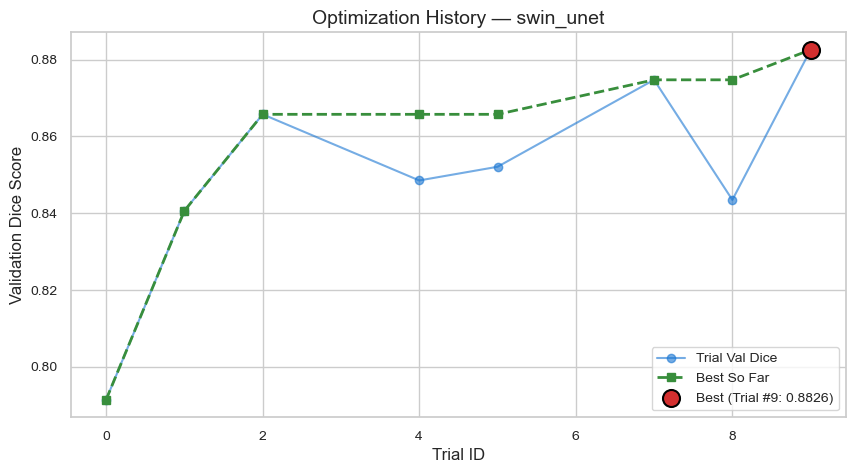

In [3]:
# Plot 1: Optimization History
plt.figure(figsize=(10, 5))
running_max = np.maximum.accumulate(df["dice"].values)

plt.plot(df["trial_id"], df["dice"], "o-", color=PRIMARY_COLOR, label="Trial Val Dice", alpha=0.6)
plt.plot(df["trial_id"], running_max, "s--", color=SECONDARY_COLOR, label="Best So Far", linewidth=2)

best_idx = df["dice"].idxmax()
plt.scatter(
    df.loc[best_idx, "trial_id"], df.loc[best_idx, "dice"],
    color=ACCENT_COLOR, s=150, zorder=5, edgecolor="black", linewidth=1.5,
    label=f"Best (Trial #{df.loc[best_idx, 'trial_id']}: {df.loc[best_idx, 'dice']:.4f})"
)

plt.title(f"Optimization History — {model_name}")
plt.xlabel("Trial ID")
plt.ylabel("Validation Dice Score")
plt.legend(loc="lower right")
plt.show()


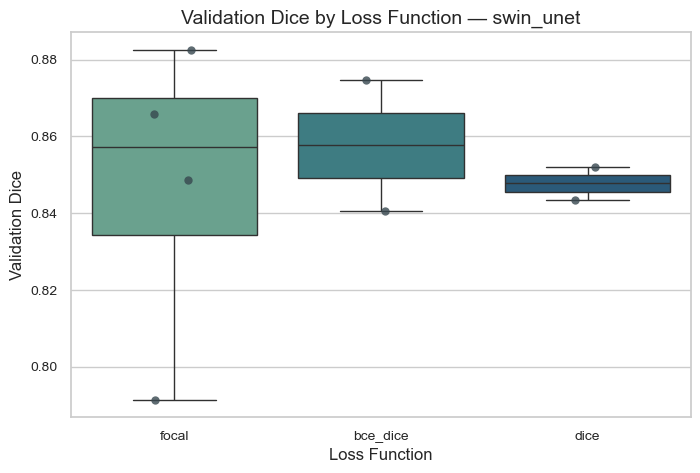

In [4]:
# Plot 2: Loss Function Performance
plt.figure(figsize=(8, 5))
sns.boxplot(x="loss", y="dice", data=df, palette="crest", hue="loss", legend=False)
sns.stripplot(x="loss", y="dice", data=df, color=DARK_NEUTRAL, size=6, jitter=0.1, alpha=0.8)

plt.title(f"Validation Dice by Loss Function — {model_name}")
plt.xlabel("Loss Function")
plt.ylabel("Validation Dice")
plt.show()


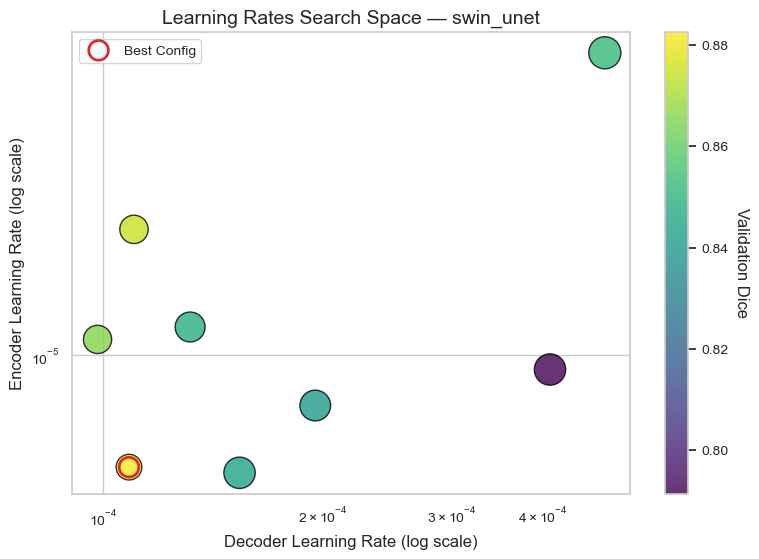

In [5]:
# Plot 3: Learning Rate vs Dice (Scatter)
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    df["lr"], df["encoder_lr"],
    c=df["dice"], cmap="viridis",
    s=df["duration_sec"] * 0.1 + 50,
    edgecolors="black", alpha=0.8
)
cbar = plt.colorbar(scatter)
cbar.set_label("Validation Dice", rotation=270, labelpad=15)

plt.xscale("log")
plt.yscale("log")
plt.title(f"Learning Rates Search Space — {model_name}")
plt.xlabel("Decoder Learning Rate (log scale)")
plt.ylabel("Encoder Learning Rate (log scale)")

plt.scatter(
    best_row["lr"], best_row["encoder_lr"],
    facecolors="none", edgecolors=ACCENT_COLOR, s=200, linewidths=2,
    label="Best Config"
)
plt.legend()
plt.show()
